In [ ]:
# correlation

import numpy as np

advertising = [10,20,30,40,50] # X
sales = [100,140,180,210,260]  # Y


# numpy : np.corrcoeff(x,y)

correlation_matrix = np.corrcoef(advertising,sales)

print(correlation_matrix)




[[1.         0.99770679]
 [0.99770679 1.        ]]


{'Advertising': [10, 20, 30, 40, 50], 'Sales': [100, 140, 180, 210, 260], 'Price': [50, 48, 45, 43, 40]}
<class 'dict'>
   Advertising  Sales  Price
0           10    100     50
1           20    140     48
2           30    180     45
3           40    210     43
4           50    260     40
Printing correlation...

             Advertising     Sales     Price
Advertising     1.000000  0.997707 -0.997609
Sales           0.997707  1.000000 -0.998383
Price          -0.997609 -0.998383  1.000000


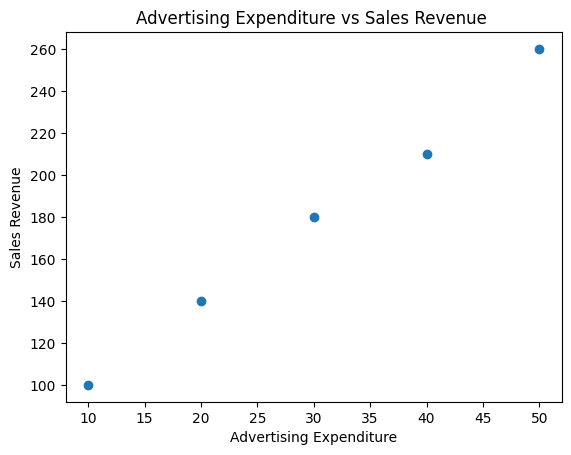

In [ ]:
# using pandas

import pandas as pd


data = {
    "Advertising" : [10,20,30,40,50],
    "Sales" : [100,140,180,210,260],
    "Price" : [50,48,45,43,40]
}
print(data)
print(type(data))

# convert dictionary into dataframe
print("="*40)
df = pd.DataFrame(data)
print(df)
print("="*40)
print("Printing correlation...\n")

print(df.corr()) # give me the correlation for the dataframe


# visualize the correlation - matplotlib :scatterplot

import matplotlib.pyplot as plt

plt.scatter(df["Advertising"] , df["Sales"]) # scatter plot (x,y)
plt.xlabel("Advertising Expenditure")
plt.ylabel("Sales Revenue")
plt.title("Advertising Expenditure vs Sales Revenue ")
plt.show()

In [ ]:
# 2nd dataset : there are 2 sheets : Campaign data sheet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
# read the dataset
DATA_FILE = "/content/campaign_data_100_records.xlsx"
df = pd.read_excel(DATA_FILE)


df.head(10)

,Campaign_ID,Ad_Spend_000_INR,Discount_Percent,Website_Visits,Orders,Revenue_000_INR
0,CMP-001,118,17,6028,183,215
1,CMP-002,135,22,6479,220,258
2,CMP-003,152,9,8699,275,364
3,CMP-004,114,16,5977,181,197
4,CMP-005,137,15,8263,231,276
5,CMP-006,152,7,7205,212,292
6,CMP-007,142,16,7101,203,243
7,CMP-008,330,24,16522,508,569
8,CMP-009,80,9,4815,143,190
9,CMP-010,153,18,8727,272,341


In [ ]:
print("Columns:", df.columns , "with the shape of : ", df.shape)

Columns: Index(['Campaign_ID', 'Ad_Spend_000_INR', 'Discount_Percent', 'Website_Visits',
       'Orders', 'Revenue_000_INR'],
      dtype='object') with the shape of :  (100, 6)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Campaign_ID       100 non-null    object
 1   Ad_Spend_000_INR  100 non-null    int64 
 2   Discount_Percent  100 non-null    int64 
 3   Website_Visits    100 non-null    int64 
 4   Orders            100 non-null    int64 
 5   Revenue_000_INR   100 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 4.8+ KB


In [ ]:
# if check missing values
# total number of NULL values per column in the dataset
print(df.isna().sum())

Campaign_ID         0
Ad_Spend_000_INR    0
Discount_Percent    0
Website_Visits      0
Orders              0
Revenue_000_INR     0
dtype: int64


In [ ]:
print("Duplicated rows: " , df.duplicated().sum())

Duplicated rows:  0


In [ ]:
# Campaign_ID column is an identifier , not a measurement
# list of numeric columns

numeric_columns = [
    'Ad_Spend_000_INR', 'Discount_Percent', 'Website_Visits','Orders', 'Revenue_000_INR'
]

# on the above numeric columns, apply descriptive stats

print("\nDescriptive Stats : ")

df[numeric_columns].describe().round(2)


Descriptive Stats : 


,Ad_Spend_000_INR,Discount_Percent,Website_Visits,Orders,Revenue_000_INR
count,100.00,100.00,100.00,100.00,100.00
mean,131.66,15.84,7015.23,232.14,307.68
std,45.14,6.82,2996.07,110.14,208.71
min,80.00,6.00,3835.00,115.00,137.00
25%,111.50,11.75,5697.25,179.00,214.50
50%,127.00,15.00,6499.00,211.50,260.50
75%,141.00,18.00,7299.50,244.00,298.00
max,395.00,55.00,20500.00,790.00,1480.00


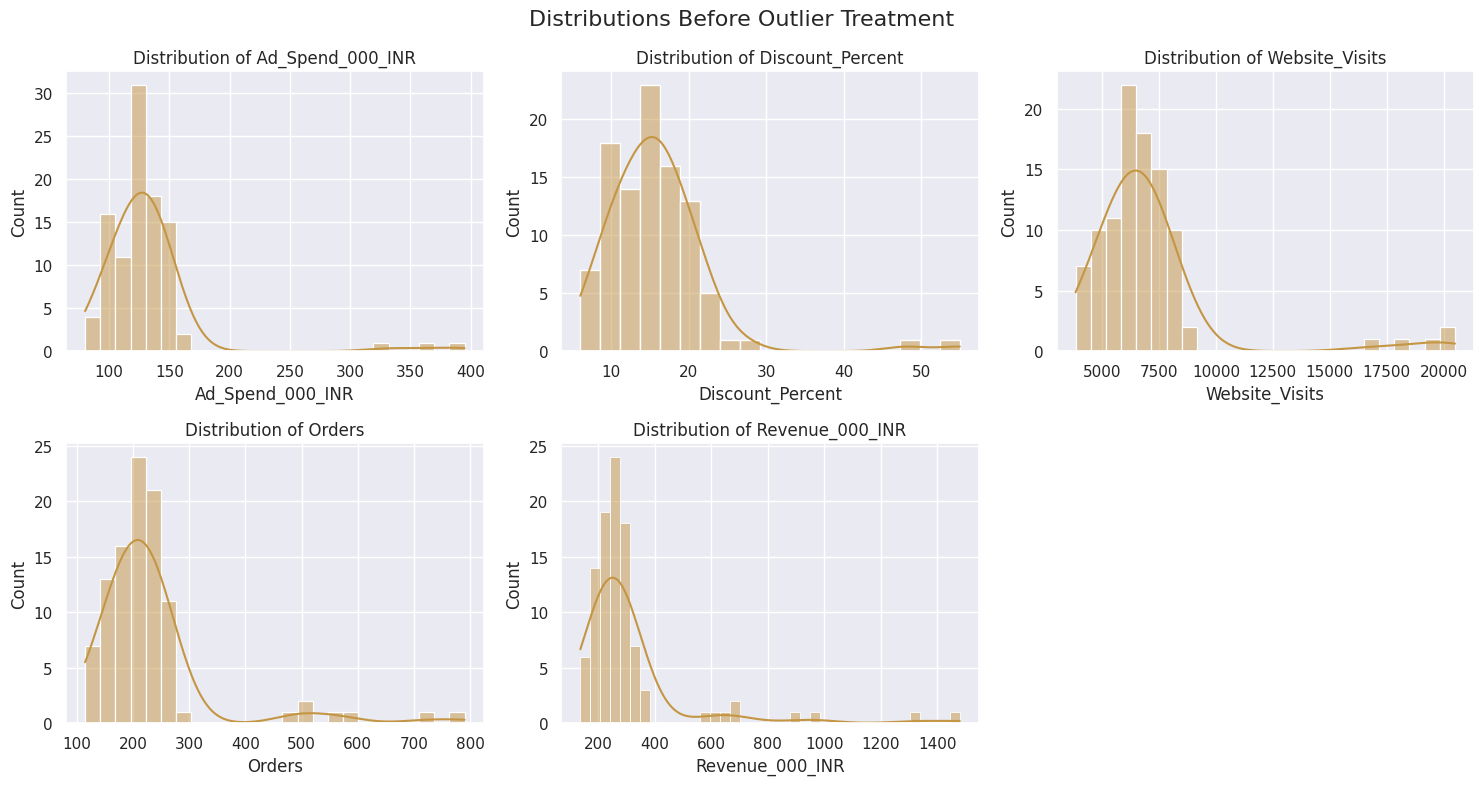

In [ ]:
# visualize original distributions

import seaborn as sns

sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(numeric_columns):
  # for each column we are building a histogram plot
    sns.histplot(df[column], kde=True, ax=axes[index], color="#C49644")
    axes[index].set_title(f"Distribution of {column}")

axes[-1].axis("off")
fig.suptitle("Distributions Before Outlier Treatment", fontsize=16)
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "01_distributions_before.png", dpi=150)
plt.show()

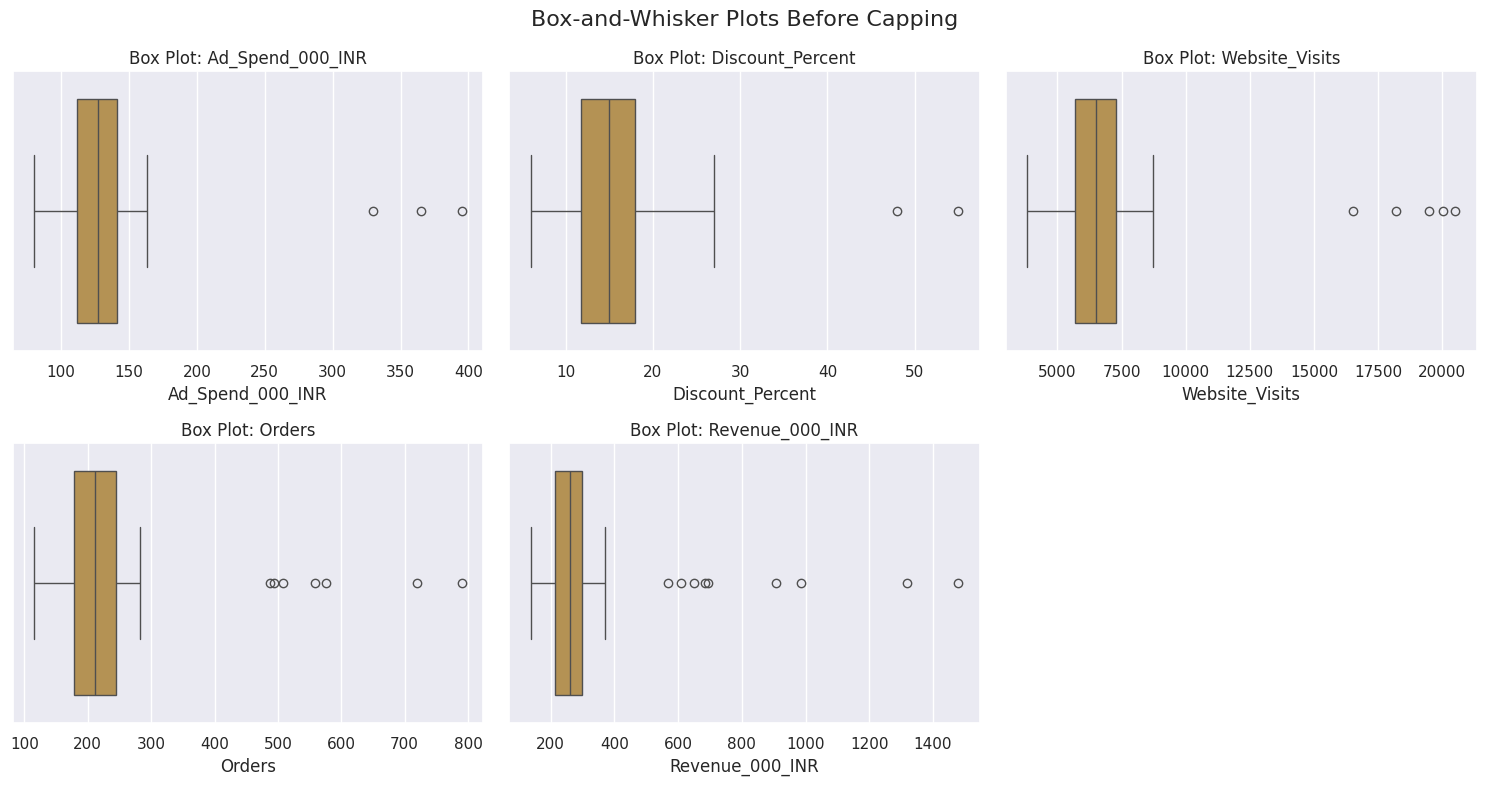

In [ ]:
# display the outliers using box whisker plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(numeric_columns):
    sns.boxplot(x=df[column], ax=axes[index], color="#C49644")
    axes[index].set_title(f"Box Plot: {column}")

axes[-1].axis("off")
fig.suptitle("Box-and-Whisker Plots Before Capping", fontsize=16)
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "02_boxplots_before.png", dpi=150)
plt.show()


In [ ]:
# detect the outliers with the IQR method


def calculate_iqr_limits(series):
    """Return quartiles and the standard 1.5 × IQR outlier fences."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    return q1, q3, iqr, lower_limit, upper_limit


outlier_summary = []
outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_columns)

for column in numeric_columns:
    q1, q3, iqr, lower_limit, upper_limit = calculate_iqr_limits(df[column])

    column_flags = (df[column] < lower_limit) | (df[column] > upper_limit)
    outlier_flags[column] = column_flags
    # this shows us all the columns in the dataset
    # which contain at atleast 1 outlier

    outlier_summary.append({
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Limit": lower_limit,
        "Upper_Limit": upper_limit,
        "Outlier_Count": int(column_flags.sum()),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("\nSTEP 5: IQR OUTLIER SUMMARY")
print(outlier_summary_df.round(2).to_string(index=False))

# Display complete records containing at least one outlier.
rows_with_outliers = df.loc[outlier_flags.any(axis=1)].copy()
rows_with_outliers["Outlier_In"] = outlier_flags.loc[
    outlier_flags.any(axis=1)
].apply(lambda row: ", ".join(row.index[row]), axis=1)

print("\nRecords containing at least one outlier")
print(rows_with_outliers.to_string(index=False))


STEP 5: IQR OUTLIER SUMMARY
          Column      Q1     Q3     IQR  Lower_Limit  Upper_Limit  Outlier_Count
Ad_Spend_000_INR  111.50  141.0   29.50        67.25       185.25              3
Discount_Percent   11.75   18.0    6.25         2.38        27.38              2
  Website_Visits 5697.25 7299.5 1602.25      3293.88      9702.88              5
          Orders  179.00  244.0   65.00        81.50       341.50              7
 Revenue_000_INR  214.50  298.0   83.50        89.25       423.25              9

Records containing at least one outlier
Campaign_ID  Ad_Spend_000_INR  Discount_Percent  Website_Visits  Orders  Revenue_000_INR                                                Outlier_In
    CMP-008               330                24           16522     508              569 Ad_Spend_000_INR, Website_Visits, Orders, Revenue_000_INR
    CMP-016               136                16           18200     488              609                   Website_Visits, Orders, Revenue_000_INR
   


STEP 6: CORRELATION BEFORE CAPPING
                  Ad_Spend_000_INR  Discount_Percent  Website_Visits  Orders  \
Ad_Spend_000_INR              1.00             -0.05            0.80    0.55   
Discount_Percent             -0.05              1.00           -0.05    0.12   
Website_Visits                0.80             -0.05            1.00    0.68   
Orders                        0.55              0.12            0.68    1.00   
Revenue_000_INR               0.38              0.02            0.47    0.67   

                  Revenue_000_INR  
Ad_Spend_000_INR             0.38  
Discount_Percent             0.02  
Website_Visits               0.47  
Orders                       0.67  
Revenue_000_INR              1.00  


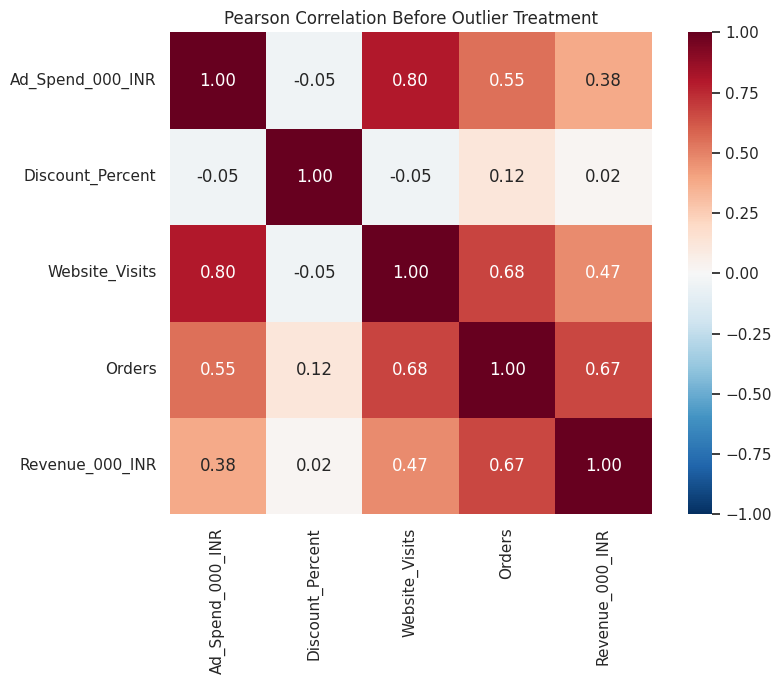

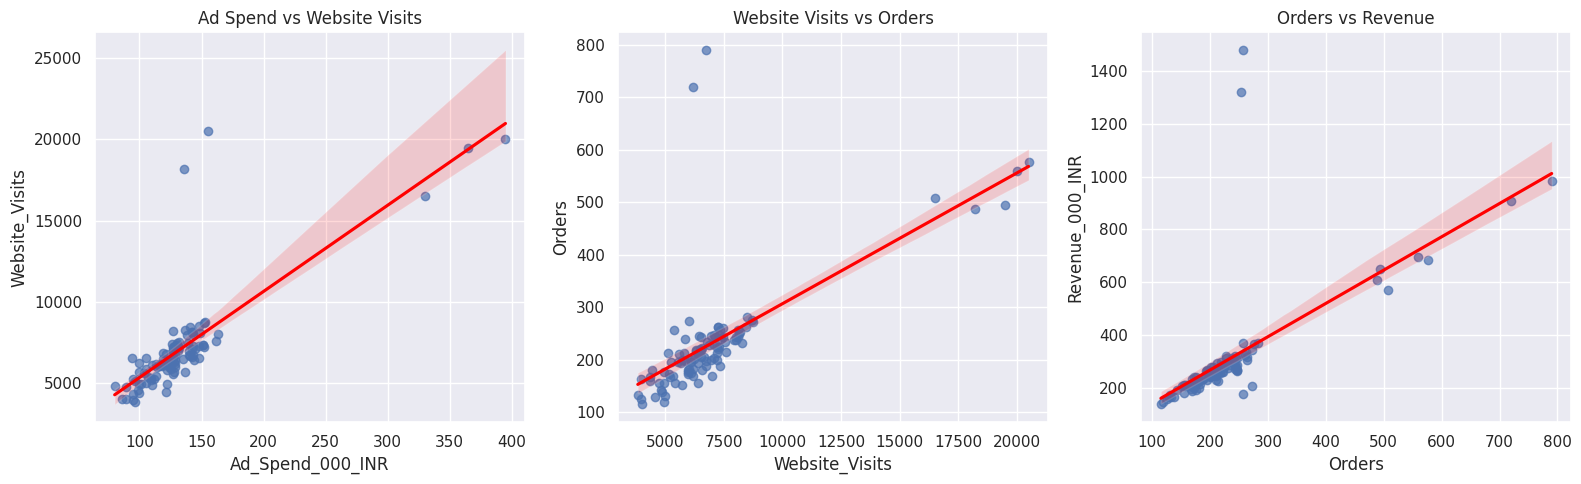

In [ ]:
# correlation before the outlier treatment

correlation_before = df[numeric_columns].corr(method="pearson")

print("\nSTEP 6: CORRELATION BEFORE CAPPING")
print(correlation_before.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_before,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
)
plt.title("Pearson Correlation Before Outlier Treatment")
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "03_correlation_before.png", dpi=150)
plt.show()


# Scatter plots help us verify what a correlation coefficient is summarising.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.regplot(
    data=df,
    x="Ad_Spend_000_INR",
    y="Website_Visits",
    ax=axes[0],
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
)
axes[0].set_title("Ad Spend vs Website Visits")

sns.regplot(
    data=df,
    x="Website_Visits",
    y="Orders",
    ax=axes[1],
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
)
axes[1].set_title("Website Visits vs Orders")

sns.regplot(
    data=df,
    x="Orders",
    y="Revenue_000_INR",
    ax=axes[2],
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
)
axes[2].set_title("Orders vs Revenue")

plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "04_relationships_before.png", dpi=150)
plt.show()

In [ ]:
# Outlier treatment : Winsorization method
# Important: no rows are deleted.
# Values below the lower fence are replaced by the lower fence.
# Values above the upper fence are replaced by the upper fence.
capped_df = df.copy()
cap_summary = []

for column in numeric_columns:
    _, _, _, lower_limit, upper_limit = calculate_iqr_limits(df[column])

    original_values = capped_df[column].copy()
    capped_df[column] = capped_df[column].clip(
        lower=lower_limit,
        upper=upper_limit,
    )

    cap_summary.append({
        "Column": column,
        "Lower_Cap": lower_limit,
        "Upper_Cap": upper_limit,
        "Values_Changed": int((original_values != capped_df[column]).sum()),
    })

cap_summary_df = pd.DataFrame(cap_summary)

print("\nSTEP 7: CAPPING SUMMARY")
print(cap_summary_df.round(2).to_string(index=False))
print("\nRows before capping:", len(df))
print("Rows after capping: ", len(capped_df))


STEP 7: CAPPING SUMMARY
          Column  Lower_Cap  Upper_Cap  Values_Changed
Ad_Spend_000_INR      67.25     185.25               3
Discount_Percent       2.38      27.38               2
  Website_Visits    3293.88    9702.88               5
          Orders      81.50     341.50               7
 Revenue_000_INR      89.25     423.25               9

Rows before capping: 100
Rows after capping:  100


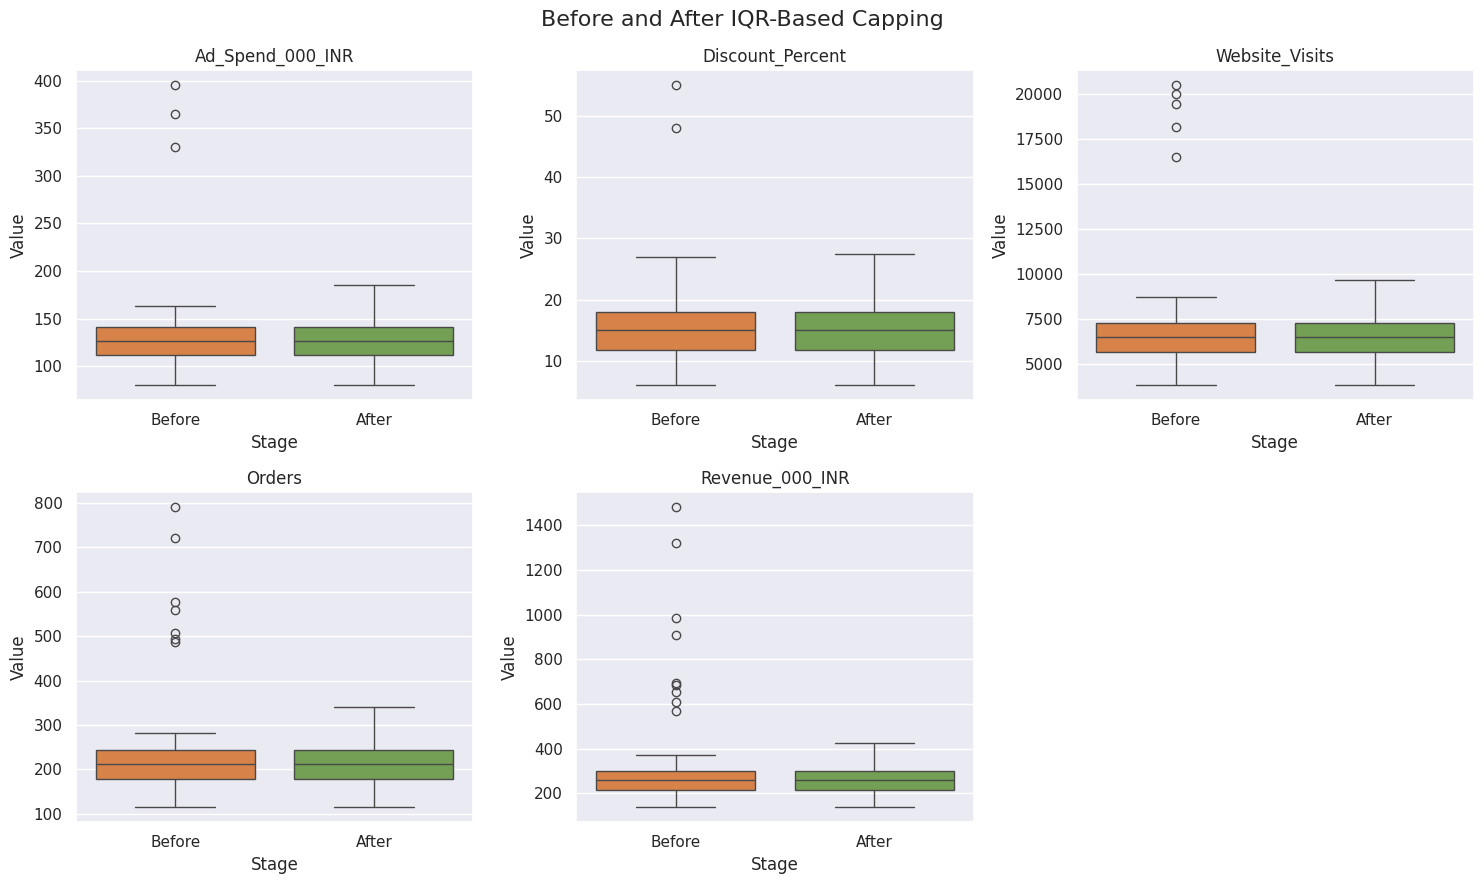

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for index, column in enumerate(numeric_columns):
    comparison_data = pd.DataFrame({
        "Before": df[column],
        "After": capped_df[column],
    }).melt(var_name="Stage", value_name="Value")

    sns.boxplot(
        data=comparison_data,
        x="Stage",
        y="Value",
        ax=axes[index],
        palette=["#ED7D31", "#70AD47"],
        hue="Stage",
        legend=False,
    )
    axes[index].set_title(column)

axes[-1].axis("off")
fig.suptitle("Before and After IQR-Based Capping", fontsize=16)
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "05_boxplots_before_after.png", dpi=150)
plt.show()


STEP 9: CORRELATION AFTER CAPPING
                  Ad_Spend_000_INR  Discount_Percent  Website_Visits  Orders  \
Ad_Spend_000_INR              1.00             -0.01            0.84    0.65   
Discount_Percent             -0.01              1.00           -0.03    0.23   
Website_Visits                0.84             -0.03            1.00    0.80   
Orders                        0.65              0.23            0.80    1.00   
Revenue_000_INR               0.66             -0.04            0.81    0.90   

                  Revenue_000_INR  
Ad_Spend_000_INR             0.66  
Discount_Percent            -0.04  
Website_Visits               0.81  
Orders                       0.90  
Revenue_000_INR              1.00  


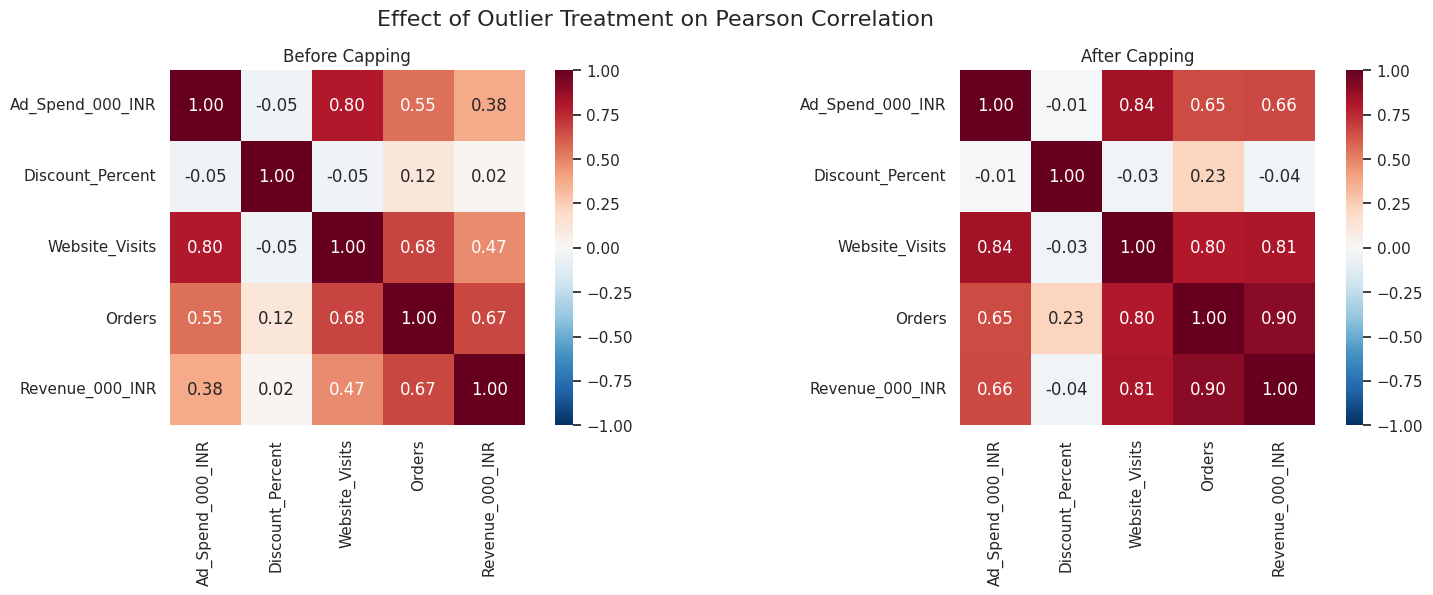

In [ ]:
correlation_after = capped_df[numeric_columns].corr(method="pearson")

print("\nSTEP 9: CORRELATION AFTER CAPPING")
print(correlation_after.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    correlation_before,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    ax=axes[0],
)
axes[0].set_title("Before Capping")

sns.heatmap(
    correlation_after,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    ax=axes[1],
)
axes[1].set_title("After Capping")

fig.suptitle("Effect of Outlier Treatment on Pearson Correlation", fontsize=16)
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "06_correlation_before_after.png", dpi=150)
plt.show()



In [ ]:
# QUANTIFY HOW CORRELATIONS CHANGED
correlation_change = correlation_after - correlation_before

print("\nSTEP 10: CHANGE IN CORRELATION (AFTER - BEFORE)")
print(correlation_change.round(3))

orders_comparison = pd.DataFrame({
    "Before_Capping": correlation_before["Orders"],
    "After_Capping": correlation_after["Orders"],
})
orders_comparison["Absolute_Change"] = (
    orders_comparison["After_Capping"]
    - orders_comparison["Before_Capping"]
).abs()
orders_comparison = orders_comparison.drop(index="Orders")

print("\nCorrelation of each variable with Orders")
print(orders_comparison.round(3).sort_values("Absolute_Change", ascending=False))


STEP 10: CHANGE IN CORRELATION (AFTER - BEFORE)
                  Ad_Spend_000_INR  Discount_Percent  Website_Visits  Orders  \
Ad_Spend_000_INR             0.000             0.038           0.038   0.106   
Discount_Percent             0.038             0.000           0.010   0.105   
Website_Visits               0.038             0.010           0.000   0.123   
Orders                       0.106             0.105           0.123   0.000   
Revenue_000_INR              0.279            -0.057           0.344   0.234   

                  Revenue_000_INR  
Ad_Spend_000_INR            0.279  
Discount_Percent           -0.057  
Website_Visits              0.344  
Orders                      0.234  
Revenue_000_INR             0.000  

Correlation of each variable with Orders
                  Before_Capping  After_Capping  Absolute_Change
Revenue_000_INR            0.666          0.900            0.234
Website_Visits             0.678          0.801            0.123
Ad_Spend_000_INR 